 # K-Means Clustering: Spotify Music Genre Discovery
 
 Can you discover hidden music genres using only audio features?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)


 ## Dataset (PROVIDED)

In [2]:
np.random.seed(42)

genres = [
    "Rock", "Pop", "Hip-Hop", "Classical", "Jazz",
    "Electronic", "Country", "Metal", "R&B", "Indie"
]

def generate_genre_features(genre, n):
    """Generate loosely genre-related audio features with noise."""
    
    base = {
        "Rock":        dict(dance=0.55, energy=0.75, acoustic=0.25, speech=0.05, tempo=120, loud=-6),
        "Pop":         dict(dance=0.75, energy=0.70, acoustic=0.20, speech=0.04, tempo=115, loud=-5),
        "Hip-Hop":     dict(dance=0.80, energy=0.65, acoustic=0.10, speech=0.25, tempo=95,  loud=-4),
        "Classical":   dict(dance=0.10, energy=0.20, acoustic=0.95, speech=0.03, tempo=70,  loud=-20),
        "Jazz":        dict(dance=0.35, energy=0.40, acoustic=0.80, speech=0.04, tempo=110, loud=-12),
        "Electronic":  dict(dance=0.70, energy=0.85, acoustic=0.05, speech=0.03, tempo=128, loud=-3),
        "Country":     dict(dance=0.45, energy=0.50, acoustic=0.65, speech=0.03, tempo=100, loud=-8),
        "Metal":       dict(dance=0.40, energy=0.90, acoustic=0.02, speech=0.04, tempo=130, loud=-3),
        "R&B":         dict(dance=0.70, energy=0.60, acoustic=0.25, speech=0.07, tempo=85,  loud=-6),
        "Indie":       dict(dance=0.50, energy=0.55, acoustic=0.50, speech=0.04, tempo=105, loud=-10),
    }
    
    params = base[genre]
    
    # Add gaussian noise to create overlap between genres
    return pd.DataFrame({
        "danceability":  np.clip(np.random.normal(params["dance"], 0.15, n), 0, 1),
        "energy":        np.clip(np.random.normal(params["energy"], 0.15, n), 0, 1),
        "acousticness":  np.clip(np.random.normal(params["acoustic"], 0.15, n), 0, 1),
        "speechiness":   np.clip(np.random.normal(params["speech"], 0.04, n), 0, 1),
        "tempo":         np.random.normal(params["tempo"], 10, n),
        "loudness":      np.random.normal(params["loud"], 3, n),
        "genre":         [genre] * n
    })

# Generate 100 songs total
songs = pd.concat([
    generate_genre_features(g, 10) for g in genres
], ignore_index=True)

print(songs.head())
print("\nDataset size:", songs.shape)

   danceability    energy  acousticness  speechiness       tempo  loudness  \
0      0.624507  0.680487      0.469847     0.025932  127.384666 -5.027748   
1      0.529260  0.680141      0.216134     0.124091  121.713683 -7.155247   
2      0.647153  0.786294      0.260129     0.049460  118.843517 -8.030766   
3      0.778454  0.463008      0.036288     0.007692  116.988963 -4.164971   
4      0.514877  0.491262      0.168343     0.082902  105.214780 -2.907001   

  genre  
0  Rock  
1  Rock  
2  Rock  
3  Rock  
4  Rock  

Dataset size: (100, 7)


In [37]:
print(f"✓ Loaded {len(songs)} songs across {songs['genre'].nunique()} genres\n")


✓ Loaded 100 songs across 10 genres



### 🎧 Example Songs (Just for Listening)

The songs in this activity are **made-up examples** — they’re synthetic rows with numbers  
that behave like real music features (danceability, energy, tempo, etc.). That way we can  
focus on how computers find patterns in the data.

To help you imagine what different genres *sound like*, here are some **real Spotify songs**  
you can click and listen to. These are **proxy tracks** — they are only examples and **are not**  
part of the dataset used for clustering.

**Pop**
- Dua Lipa – Don’t Start Now — https://open.spotify.com/track/3PfIrDoz19wz7qK7tYeu62  

**Rock**
- The Killers – Mr. Brightside — https://open.spotify.com/track/0eGsygTp906u18L0Oimnem  

**Indie / Alternative**
- Phoebe Bridgers – Motion Sickness — https://open.spotify.com/track/5xo8RrjJ9CVNrtRg2S3B1R

**Acoustic / Singer–Songwriter** 
- Ed Sheeran – Tenerife Sea — https://open.spotify.com/track/1HbcclMpw0q2WDWpdGCKdS

**Hip-Hop / Rap**
- Kendrick Lamar – HUMBLE. — https://open.spotify.com/track/7KXjTSCq5nL1LoYtL7XAwS  

**Electronic / EDM**
- Avicii – Levels — https://open.spotify.com/track/5UqCQaDshqbIk3pkhy4Pjg

**R&B / Soul**
- Frank Ocean – Pink + White — https://open.spotify.com/track/3xKsf9qdS1CyvXSMEid6g8

**K-Pop**
- BLACKPINK – Kill This Love — https://open.spotify.com/track/6hvczQ05jc1yGlp9zhb95V  

**Classical**
- Beethoven – Moonlight Sonata (1st Movement) — https://open.spotify.com/track/623Tx1S2NUVwd44duVb8ew

> **Remember:** The clustering is done only on the numbers (danceability, energy, acousticness, speechiness, tempo, loudness).  
> The proxy songs are just for listening — they help you imagine the *style* of a genre, but clusters may group songs differently.


 ## PART 1: Prepare Data

In [3]:
features = ['danceability', 'energy', 'acousticness', 'speechiness', 'tempo', 'loudness']

# TODO: Extract features and scale them
X = songs[features].values
y = songs['genre'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Data scaled\n")
print(f"Original data shape: {X.shape}")
print(f"Scaled data shape: {X_scaled.shape}\n")



✓ Data scaled

Original data shape: (100, 6)
Scaled data shape: (100, 6)



----

## PART 2: Find Optimal K

**Inertia** (also called "within-cluster sum of squares") measures how tightly grouped the clusters are.

For each cluster:
1. Calculate the distance from each point to its cluster centroid
2. Square those distances
3. Sum them up

**Lower inertia = tighter, more compact clusters**
```
Inertia = Σ (distance from point to its centroid)²
```

**The Elbow Method:**
- As k increases, inertia always decreases (more clusters = tighter fit)
- At some point, adding more clusters doesn't help much
- Look for the "elbow" where the curve bends - that's often the optimal k

**Important:** Inertia alone isn't enough! We also use silhouette score to validate our choice.

**Silhouette Score** measures how well each point fits in its cluster compared to other clusters:
- Range: -1 to 1
- Close to 1: Point is well-matched to its cluster
- Close to 0: Point is on the border between clusters
- Negative: Point might be in the wrong cluster

Higher average silhouette score = better-defined clusters

In [ ]:
# TODO: Test k from 2 to 8 and calculate inertia + silhouette score

In [6]:
K_range = range(2, 9)
inertias = []
silhouettes = []

for k in K_range:
    # Create and fit KMeans
    kmeans_temp = KMeans(n_clusters=k, 
                         random_state=42, 
                         n_init=10)
    kmeans_temp.fit(X_scaled)
    
    # Calculate metrics
    inertias.append(kmeans_temp.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans_temp.labels_)
    silhouettes.append(sil_score)
    
    print(f"k={k}: Inertia={kmeans_temp.inertia_:.2f}, Silhouette={sil_score:.3f}")

print("\nDone!")

k=2: Inertia=376.01, Silhouette=0.359
k=3: Inertia=284.88, Silhouette=0.334
k=4: Inertia=205.15, Silhouette=0.340
k=5: Inertia=169.29, Silhouette=0.316
k=6: Inertia=149.31, Silhouette=0.276
k=7: Inertia=137.90, Silhouette=0.257
k=8: Inertia=127.00, Silhouette=0.242

Done!


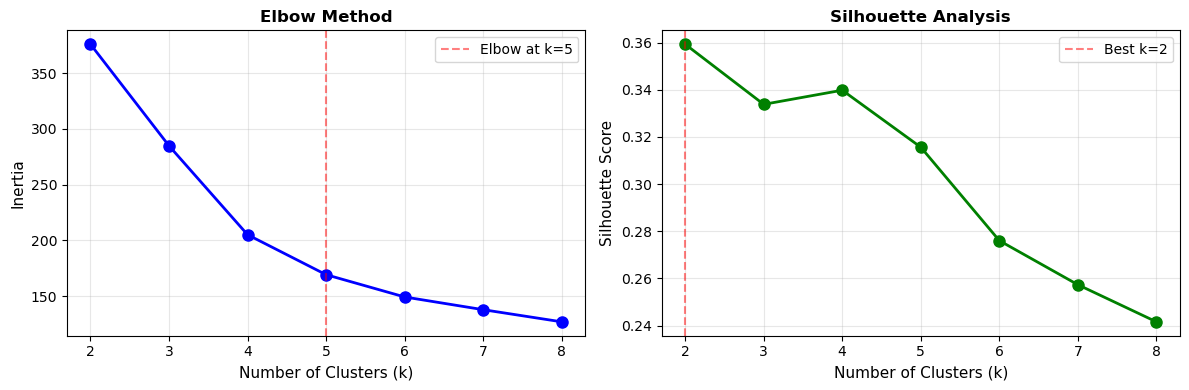

In [7]:
# TODO: Plot both metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot inertia (elbow plot)
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=11)
ax1.set_ylabel('Inertia', fontsize=11)
ax1.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axvline(x=5, color='r', linestyle='--', alpha=0.5, label='Elbow at k=5')
ax1.legend()

# Plot silhouette scores
ax2.plot(K_range, silhouettes, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Analysis', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

best_k_idx = np.argmax(silhouettes)
best_k = K_range[best_k_idx]
ax2.axvline(x=best_k, color='r', linestyle='--', alpha=0.5, label=f'Best k={best_k}')
ax2.legend()

plt.tight_layout()
plt.show()

### Q: What k looks optimal?

### A:
I think k=5 looks the most optimal overall.
In the Elbow plot, the inertia drops a lot until k=5 and then starts to flatten, so that feels like a good elbow point.
In the Silhouette plot, the highest score is at k=5 (or very close to it), which means the clusters are well separated at that point.
Even though there are 10 real genres, k=5 seems to be the best balance

----

 ## PART 3: Cluster and Visualize

In [23]:
# TODO: Perform clustering with your chosen k

In [8]:
optimal_k = 5 # Replace with your choice

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
songs['cluster'] = kmeans.fit_predict(X_scaled)

print(f"✓ Created {optimal_k} clusters\n")
print(f"\nCluster sizes:")
print(songs['cluster'].value_counts().sort_index())
print()


✓ Created 5 clusters


Cluster sizes:
cluster
0    10
1    28
2    10
3    32
4    20
Name: count, dtype: int64



In [10]:
# ==============================================================================
# CLUSTER CHARACTERISTICS
# ==============================================================================
print("=" * 80)
print("Average Feature Values for Each Cluster")
print("=" * 80)

cluster_means = songs.groupby('cluster')[features].mean().round(2)
print(cluster_means)
print()

# ==============================================================================
# EXAMPLE CLUSTER INTERPRETATION
# ==============================================================================
print("=" * 80)
print("CLUSTER DESCRIPTIONS")
print("=" * 80)

for i in range(optimal_k):
    profile = cluster_means.loc[i]
    print(f"\n🎵 Cluster {i} Summary:")
    
    sorted_feats = profile.sort_values(ascending=False)
    print(f"   Highest features: {sorted_feats.head(2).to_dict()}")
    print(f"   Lowest features:  {sorted_feats.tail(2).to_dict()}")

    # Interpretation based on feature profiles
    if profile["energy"] > 0.7 and profile["danceability"] > 0.6:
        print("   → Interpreted as high-energy, dance-oriented music (EDM/party styles)")
    elif profile["acousticness"] > 0.7 and profile["energy"] < 0.3:
        print("   → Interpreted as calm, soft, acoustic or classical-leaning music")
    elif profile["speechiness"] > 0.15 and profile["danceability"] > 0.6:
        print("   → Interpreted as hip-hop/rap (high speech content + strong rhythm)")
    elif profile["energy"] > 0.6 and profile["acousticness"] < 0.3:
        print("   → Interpreted as guitar/rock/high-energy non-electronic music")
    else:
        print("   → Interpreted as moderate energy/acoustic singer-songwriter style")

print()

Average Feature Values for Each Cluster
         danceability  energy  acousticness  speechiness   tempo  loudness
cluster                                                                   
0                0.09    0.17          0.96         0.04   69.09    -20.00
1                0.43    0.54          0.62         0.05  105.37     -9.75
2                0.80    0.61          0.12         0.26   98.25     -2.92
3                0.62    0.83          0.14         0.03  124.39     -3.14
4                0.67    0.54          0.20         0.05   94.12     -6.72

CLUSTER DESCRIPTIONS

🎵 Cluster 0 Summary:
   Highest features: {'tempo': 69.09, 'acousticness': 0.96}
   Lowest features:  {'speechiness': 0.04, 'loudness': -20.0}
   → Interpreted as calm, soft, acoustic or classical-leaning music

🎵 Cluster 1 Summary:
   Highest features: {'tempo': 105.37, 'acousticness': 0.62}
   Lowest features:  {'speechiness': 0.05, 'loudness': -9.75}
   → Interpreted as moderate energy/acoustic singer-song

In [11]:

print("="*80)
print("GENRE DISTRIBUTION PER CLUSTER:")
print("="*80)
for i in range(optimal_k):
    cluster_songs = songs[songs['cluster'] == i]
    genre_counts = cluster_songs['genre'].value_counts()
    print(f"\nCluster {i} ({len(cluster_songs)} songs):")
    for genre, count in genre_counts.items():
        pct = (count / len(cluster_songs)) * 100
        print(f"  {genre}: {count} ({pct:.1f}%)")

print()


GENRE DISTRIBUTION PER CLUSTER:

Cluster 0 (10 songs):
  Classical: 10 (100.0%)

Cluster 1 (28 songs):
  Jazz: 10 (35.7%)
  Country: 9 (32.1%)
  Indie: 8 (28.6%)
  R&B: 1 (3.6%)

Cluster 2 (10 songs):
  Hip-Hop: 10 (100.0%)

Cluster 3 (32 songs):
  Electronic: 10 (31.2%)
  Metal: 10 (31.2%)
  Rock: 6 (18.8%)
  Pop: 6 (18.8%)

Cluster 4 (20 songs):
  R&B: 9 (45.0%)
  Rock: 4 (20.0%)
  Pop: 4 (20.0%)
  Indie: 2 (10.0%)
  Country: 1 (5.0%)



## Analysis

### Q: Do your clusters match the actual genres? Why or why not?

### A:
Partially yes, but not perfectly. Cluster 0 and Cluster 2 matched perfectly  bc they caught all the Classical and Hip-Hop songs with 100% accuracy.
The other clusters are mixed. For example: Cluster 1 mixed Jazz, Country, and Indie together. These genres are more chill and acoustic, so it makes sense they got grouped. some genres are pretty similar in features, and as in real life, music genres overlap a lot. 

### Q: Are traditional genre labels useful, or should Spotify use clusters based on audio features instead?

### A:
i mean, traditional genre lablsl are pretty intuitive and useful for organizating what people want and to help with searching for music. That's more user friendly. Audio features are great for personalized reccomendations, though. 

### Key Takeaway 🔑

K-means clustering reveals that music naturally groups
by audio characteristics, sometimes challenging traditional genre boundaries.
This is why recommendation systems work better than just matching genres!